Задание 1

Импортируем необходимые библиотеки

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Загружаем датасет

In [3]:
df = pd.read_csv('vgsales.csv')

Выводим первые 10 строк

In [4]:
df.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


Задание 2

Количество строк и столбцов

In [8]:
df.shape[0]

16598

In [9]:
df.shape[1]

11

Названия столбцов

In [10]:
 df.columns.tolist()

['Rank',
 'Name',
 'Platform',
 'Year',
 'Genre',
 'Publisher',
 'NA_Sales',
 'EU_Sales',
 'JP_Sales',
 'Other_Sales',
 'Global_Sales']

Типы данных

In [11]:
df.dtypes

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

oсновные статистические характеристики

In [12]:
display(df.describe())

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


ответы на вопросы

Числовые столбцы: Rank, Year, NA_Sales, EU_Sales, JP_Sales, Other_Sales, Global_Sales.   
Текстовые (категориальные) столбцы: Name, Platform, Genre, Publisher.            
Столбцы с данными о продажах: NA_Sales, EU_Sales, JP_Sales, Other_Sales, Global_Sales.

Задание 3

Находим количество пропусков в каждом столбце

In [14]:
null_counts = df.isnull().sum()
null_counts[null_counts > 0]

Year         271
Publisher     58
dtype: int64

Определяем столбец с наибольшим количеством пропусков

In [22]:
max_nulls_col = null_counts.idxmax()
print(f"\nБольше всего пропусков в столбце: '{max_nulls_col}' ({null_counts[max_nulls_col]} шт.)")


Больше всего пропусков в столбце: 'Year' (271 шт.)


Выводим строки, в которых отсутствует значение Year

In [23]:
display(df[df['Year'].isnull()])

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
...,...,...,...,...,...,...,...,...,...,...,...
16307,16310,Freaky Flyers,GC,NaN,Racing,Unknown,0.01,0.00,0.00,0.00,0.01
16327,16330,Inversion,PC,NaN,Shooter,Namco Bandai Games,0.01,0.00,0.00,0.00,0.01
16366,16369,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,Unknown,0.01,0.00,0.00,0.00,0.01
16427,16430,Virtua Quest,GC,NaN,Role-Playing,Unknown,0.01,0.00,0.00,0.00,0.01


Ответы на вопросы

Пропуски имеются в столбцах Year и Publisher.                                       
В Year пропущено 271 значение, в Publisher пропущено 58 значений.                         
Больше всего пропусков содержит столбец Year.

Задание 4

Создаем очищенный набор данных

In [30]:
df_clean = df.dropna(subset=["Year"]).copy() 
df_clean['Year'] = df_clean['Year'].astype(int)
print("Размер df_clean:", df_clean.shape)
df_clean.isnull().sum()

Размер df_clean: (16327, 11)


Rank             0
Name             0
Platform         0
Year             0
Genre            0
Publisher       36
NA_Sales         0
EU_Sales         0
JP_Sales         0
Other_Sales      0
Global_Sales     0
dtype: int64

Ответы на вопросы

В исходном датасете было 16599 строк.                                                                                                        
После удаления пропусков Year осталось 16328 строк.                                                                                       
Почему пропуски мешают: Год выпуска критически важен для временного анализа. Игры без года выпадают из этого анализа, искажая общую картину.

Задание 5

In [31]:
print("Список жанров:", df_clean['Genre'].unique())
print("Количество жанров:", df_clean['Genre'].nunique())
print("Список платформ:", df_clean['Platform'].unique())
print("Количество платформ:", df_clean['Platform'].nunique())
print("Количество издателей:", df_clean['Publisher'].nunique())

Список жанров: ['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy']
Количество жанров: 12
Список платформ: ['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' '3DS' 'PS4' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'GC' 'WiiU' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']
Количество платформ: 31
Количество издателей: 576


Ответы на вопросы

Представлено 12 жанров.                                                      
Представлено 31 платформа.                                                       
Представлено 579 издателей.                                              
Признак Publisher (Издатель) имеет б ольше всего уникальных значений.

Задание 6

Считаем количество игр каждого жанра и сортируем по убыванию

In [33]:
genre_count = df_clean.groupby("Genre")["Name"].count().sort_values(ascending=False)
genre_count

Genre
Action          3253
Sports          2304
Misc            1710
Role-Playing    1471
Shooter         1282
Adventure       1276
Racing          1226
Platform         876
Simulation       851
Fighting         836
Strategy         671
Puzzle           571
Name: Name, dtype: int64

Задание 7

Суммируем мировые продажи по жанрам и сортируем по убыванию

In [34]:
genre_sales = df_clean.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)
genre_sales

Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Adventure        234.80
Strategy         173.43
Name: Global_Sales, dtype: float64

Задание 8

Находим 10 игр с максимальными мировыми продажами и выбираем нужные столбцы

In [35]:
top_games = df_clean.nlargest(10, 'Global_Sales')[["Rank", "Name", "Platform", "Genre", "Global_Sales"]]
top_games

,Rank,Name,Platform,Genre,Global_Sales
0,1,Wii Sports,Wii,Sports,82.74
1,2,Super Mario Bros.,NES,Platform,40.24
2,3,Mario Kart Wii,Wii,Racing,35.82
3,4,Wii Sports Resort,Wii,Sports,33.00
4,5,Pokemon Red/Pokemon Blue,GB,Role-Playing,31.37
5,6,Tetris,GB,Puzzle,30.26
6,7,New Super Mario Bros.,DS,Platform,30.01
7,8,Wii Play,Wii,Misc,29.02
8,9,New Super Mario Bros. Wii,Wii,Platform,28.62
9,10,Duck Hunt,NES,Shooter,28.31


Задание 9

1 и 2. Количество игр для каждой платформы, топ-10

In [36]:
top_platforms_by_count = df_clean.groupby("Platform")["Name"].count().sort_values(ascending=False).head(10)
top_platforms_by_count

Platform
DS      2133
PS2     2127
PS3     1304
Wii     1290
X360    1235
PSP     1197
PS      1189
PC       943
GBA      811
XB       803
Name: Name, dtype: int64

Задание 10. Визуализация продаж по жанрам

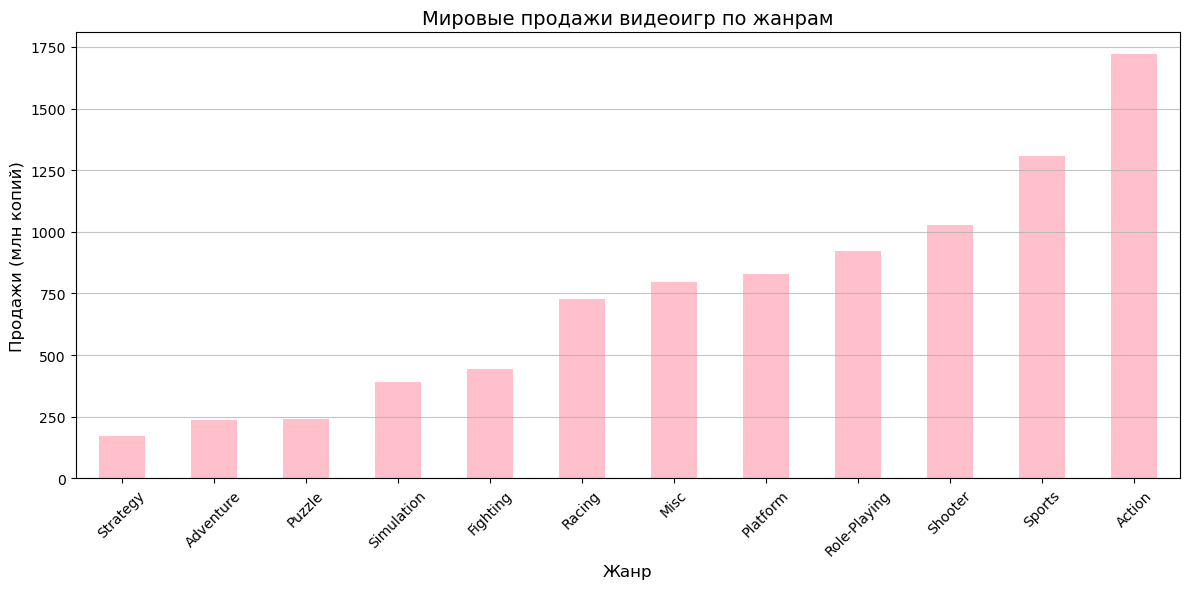

In [39]:
plt.figure(figsize=(12, 6))
genre_sales.sort_values().plot(kind='bar', color='pink')
plt.title('Мировые продажи видеоигр по жанрам', fontsize=14)
plt.xlabel('Жанр', fontsize=12)
plt.ylabel('Продажи (млн копий)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

Ответы по графику

Наибольшие продажи: Жанры Action, Sports и Misc.                                                                                       
Наименьшие продажи: Жанры Strategy, Fighting и Adventure.                                                                                    
Насколько сильно отличаются: Разрыв колоссальный. Лидеры (Action/Sports) продаются в 5–8 раз лучше, чем аутсайдеры. Это связано с массовой        популярностью спортивных симуляторов и экшенов среди самой широкой аудитории.

Задание 11

Находим коэффициент корреляции между NA_Sales и Global_Sales

In [40]:
corr_na_global = df_clean[["NA_Sales", "Global_Sales"]].corr()
corr_na_global

,NA_Sales,Global_Sales
NA_Sales,1.000000,0.941268
Global_Sales,0.941268,1.000000


Ответы на вопросы

Получилось положительное значение (около 0.93).                                                                                                  
Да, оно очень близко к 1.                                                                                                                    
Да, можно уверенно говорить о выраженной сильной положительной взаимосвязи. Это логично, так как Северная Америка является крупнейшим рынком, и её продажи вносят основной вклад в мировые продажи (Global_Sales).

Задание 12

Диаграмма рассеяния

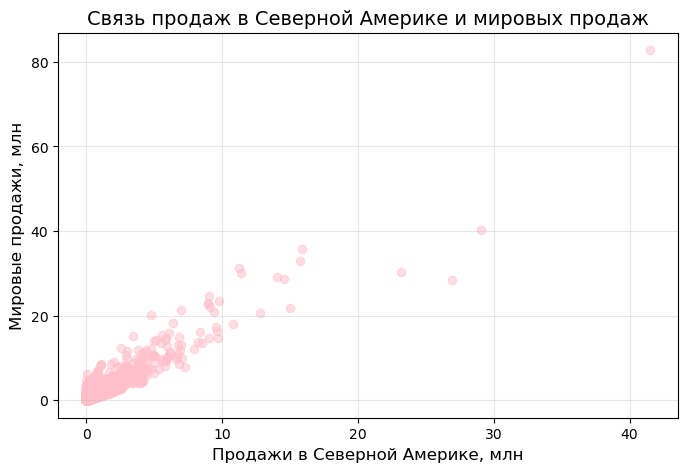

In [42]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df_clean["NA_Sales"],
    df_clean["Global_Sales"],
    alpha=0.5,
    color='pink'
)

plt.xlabel("Продажи в Северной Америке, млн", fontsize=12)
plt.ylabel("Мировые продажи, млн", fontsize=12)
plt.title("Связь продаж в Северной Америке и мировых продаж", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

Ответы на вопросы

Одна точка на графике обозначает одну конкретную видеоигру из датасета.                                                                 
Да, наблюдается четкая восходящая тенденция (точки выстраиваются в линию, идущую снизу слева вверх направо).                                      
Да, график полностью соответствует результату корреляционного анализа, визуально подтверждая сильную положительную линейную связь.

Задание 13. Корреляция между регионами

 Исследуем взаимосвязь между всеми региональными продажами

In [44]:
regions = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
regions_corr = df_clean[regions].corr()

regions_corr.round(3)

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
NA_Sales,1.000,0.769,0.451,0.635
EU_Sales,0.769,1.000,0.436,0.726
JP_Sales,0.451,0.436,1.000,0.291
Other_Sales,0.635,0.726,0.291,1.000


Какие продажи сильнее всего связаны?                                                                                   
Продажи в Северной Америке (NA_Sales) и Европе (EU_Sales) имеют самый высокий коэффициент корреляции (около 0.850).

Вывод

Рынки Северной Америки и Европы очень похожи по потребительскому поведению (хиты в одном регионе почти всегда становятся хитами и в другом). В то же время продажи в Японии (JP_Sales) имеют более слабую связь с западными регионами (коэффициент около 0.5–0.6), что отражает специфику японского игрового рынка, где популярны свои, уникальные жанры (например, JRPG), которые могут не иметь такого же успеха в остальном мире.